
# Willow

This notebook trains a small conversational chatbot from a mixed dialogue dataset.

The workflow is simple:

1. Download and inspect the source datasets.
2. Clean and normalize the text into one consistent conversation format.
3. Train a tokenizer on the cleaned training conversations.
4. Convert conversations into supervised next-token training examples.
5. Train a causal transformer model.
6. Save the best model, the final model, and a checkpoint every 5 epochs.

The notebook is written to be easy to read and easy to verify. Every data step prints examples so you can see what the project is doing before training starts.


In [1]:
!pip install -q ftfy sentencepiece datasets pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00



## Environment setup

This cell imports the libraries, checks whether a GPU is available, sets the numeric precision policy, and creates the main project folders.

If a GPU is available, training uses mixed precision for speed. If not, the notebook still works on CPU, just more slowly.


In [11]:

import io
import json
import logging
import math
import os
import random
import re
import tempfile
import unicodedata
import urllib.request
from pathlib import Path

import ftfy
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sentencepiece as spm
import tensorflow as tf

# Quiet down TensorFlow logging before the first model call.
os.environ['KERAS_BACKEND'] = 'tensorflow'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path.cwd()
CACHE_DIR = PROJECT_DIR / 'dataset_cache'
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    keras.mixed_precision.set_global_policy('mixed_float16')
    DEVICE = 'GPU'
    print(f'GPU detected: {gpus[0].name}')
else:
    keras.mixed_precision.set_global_policy('float32')
    DEVICE = 'CPU'
    print('No GPU detected — running on CPU.')

print(f'Keras version: {keras.__version__}')
print(f'Device: {DEVICE}')
print(f'Precision policy: {keras.mixed_precision.global_policy().name}')
print(f'Project directory: {PROJECT_DIR.resolve()}')
print(f'Cache directory:   {CACHE_DIR.resolve()}')
print(f'Checkpoint dir:    {CHECKPOINT_DIR.resolve()}')


No GPU detected — running on CPU.
Keras version: 3.14.0
Device: CPU
Precision policy: float32
Project directory: /home/janneesa/PycharmProjects/MetropoliaNeuralNetworkProject/chatbots/optimus
Cache directory:   /home/janneesa/PycharmProjects/MetropoliaNeuralNetworkProject/chatbots/optimus/dataset_cache
Checkpoint dir:    /home/janneesa/PycharmProjects/MetropoliaNeuralNetworkProject/chatbots/optimus/checkpoints



## Project configuration

This notebook now keeps only the settings that are still useful to tune in practice.

Most earlier text-cleaning switches have been removed so the pipeline stays stable and predictable.


In [3]:

CHATBOT_NAME = 'Optimus'

CONFIG = {
    # Dataset balance
    'max_ultrachat_conversations': 100000,

    # Text filtering
    'min_turn_chars': 2,
    'min_reply_chars': 2,

    # Tokenizer
    'vocab_size': 16000,
    'tokenizer_model_type': 'unigram',
    'tokenizer_character_coverage': 0.9995,

    # Example construction
    'max_context_turns': 6,
    'max_seq_len': 384,
    'max_examples_per_split': None,

    # Model architecture
    'd_model': 512,
    'num_heads': 8,
    'ff_dim': 2048,
    'num_layers': 8,
    'dropout': 0.15,

    # Training
    'batch_size': 64 if DEVICE == 'GPU' else 8,
    'epochs': 30,
    'learning_rate': 2e-4,
    'weight_decay': 1e-4,
    'warmup_steps': 3000,
    'early_stopping_patience': 8,
    'checkpoint_every_n_epochs': 5,

    # Generation preview
    'preview_temperature': 0.8,
    'preview_top_k': 40,
    'preview_max_new_tokens': 80,
}

print('Current configuration:')
for key, value in CONFIG.items():
    print(f'  {key:>28}: {value}')


Current configuration:
   max_ultrachat_conversations: 100000
                min_turn_chars: 2
               min_reply_chars: 2
                    vocab_size: 16000
          tokenizer_model_type: unigram
  tokenizer_character_coverage: 0.9995
             max_context_turns: 6
                   max_seq_len: 384
        max_examples_per_split: None
                       d_model: 512
                     num_heads: 8
                        ff_dim: 2048
                    num_layers: 8
                       dropout: 0.15
                    batch_size: 64
                        epochs: 30
                 learning_rate: 0.0002
                  weight_decay: 0.0001
                  warmup_steps: 3000
       early_stopping_patience: 8
     checkpoint_every_n_epochs: 5
           preview_temperature: 0.8
                 preview_top_k: 40
        preview_max_new_tokens: 80



## Download helpers

These helpers fetch remote parquet files, cache them locally, and provide a small consistent set of utilities for logging and dataset limiting.


In [4]:

def download_bytes(url: str, cache_path: Path | None = None, force: bool = False) -> bytes:
    if cache_path is not None and cache_path.exists() and not force:
        return cache_path.read_bytes()

    with urllib.request.urlopen(url) as response:
        data = response.read()

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        cache_path.write_bytes(data)

    return data


def read_parquet_from_url(url: str, cache_path: Path | None = None, force: bool = False) -> pd.DataFrame:
    data = download_bytes(url, cache_path=cache_path, force=force)
    return pd.read_parquet(io.BytesIO(data))


def _coerce_list(value) -> list:
    """Coerce a parquet field (list, tuple, numpy array, or other iterable) to a plain list."""
    if value is None:
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    if hasattr(value, 'tolist'):
        converted = value.tolist()
        if isinstance(converted, (list, tuple)):
            return list(converted)
    try:
        if hasattr(value, '__iter__') and not isinstance(value, (str, bytes, dict)):
            return list(value)
    except Exception:
        pass
    return []


def limit_conversations(conversations: list[dict], dataset_name: str, max_count: int | None = None) -> list[dict]:
    total = len(conversations)
    if max_count is None or total <= max_count:
        print(f'[{dataset_name}] Keeping all {total:,} conversations.')
        return conversations

    rng = random.Random(SEED)
    limited = conversations.copy()
    rng.shuffle(limited)
    limited = limited[:max_count]
    print(f'[{dataset_name}] Limited from {total:,} to {len(limited):,} conversations.')
    return limited


def print_dataset_preview(dataset_name: str, conversations: list[dict], n_turns: int = 4) -> None:
    print(f'[{dataset_name}] Total conversations: {len(conversations):,}')
    if not conversations:
        print(f'[{dataset_name}] No conversations loaded.')
        return

    sample = conversations[0]
    print(f'[{dataset_name}] Sample conversation id: {sample["conv_id"]}')
    for i, turn in enumerate(sample['turns'][:n_turns]):
        speaker = 'USER' if i % 2 == 0 else 'ASSISTANT'
        print(f'  {speaker}: {turn}')



## Load DailyDialog

DailyDialog provides short everyday conversations. It helps the chatbot learn normal back-and-forth dialogue.


In [5]:

def load_daily_dialog() -> list[dict]:
    base_url = (
        'https://huggingface.co/datasets/roskoN/dailydialog'
        '/resolve/refs%2Fconvert%2Fparquet/full'
    )

    frames = {}
    for split in ('train', 'validation', 'test'):
        url = f'{base_url}/{split}/0000.parquet'
        cache_path = CACHE_DIR / 'dailydialog' / f'{split}.parquet'
        print(f'[DailyDialog] Fetching {split}...')
        frames[split] = read_parquet_from_url(url, cache_path=cache_path)
        print(f'[DailyDialog] {split} rows: {len(frames[split]):,}')
        print(f'[DailyDialog] {split} columns: {list(frames[split].columns)}')

    conversations = []
    for split_name, df in frames.items():
        for row_index, row in df.iterrows():
            turns = [str(turn).strip() for turn in _coerce_list(row.get('utterances', [])) if str(turn).strip()]
            if len(turns) >= 2:
                conversations.append({
                    'source': 'daily_dialog',
                    'split': split_name,
                    'conv_id': f'dd_{split_name}_{row_index}',
                    'turns': turns,
                })

    print_dataset_preview('DailyDialog', conversations)
    return conversations


daily_dialog_conversations = load_daily_dialog()


[DailyDialog] Fetching train...
[DailyDialog] train rows: 11,118
[DailyDialog] train columns: ['id', 'acts', 'emotions', 'utterances']
[DailyDialog] Fetching validation...
[DailyDialog] validation rows: 1,000
[DailyDialog] validation columns: ['id', 'acts', 'emotions', 'utterances']
[DailyDialog] Fetching test...
[DailyDialog] test rows: 1,000
[DailyDialog] test columns: ['id', 'acts', 'emotions', 'utterances']
[DailyDialog] Total conversations: 13,118
[DailyDialog] Sample conversation id: dd_train_0
  USER: Say , Jim , how about going for a few beers after dinner ?
  ASSISTANT: You know that is tempting but is really not good for our fitness .
  USER: What do you mean ? It will help us to relax .
  ASSISTANT: Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?



## Load Blended Skill Talk

Blended Skill Talk adds more casual and persona-style conversation. This helps the chatbot sound more like a conversation partner instead of only answering direct questions.


In [6]:

def load_blended_skill_talk() -> list[dict]:
    base_url = (
        'https://huggingface.co/datasets/ParlAI/blended_skill_talk'
        '/resolve/refs%2Fconvert%2Fparquet/default'
    )

    frames = {}
    for split in ('train', 'validation', 'test'):
        url = f'{base_url}/{split}/0000.parquet'
        cache_path = CACHE_DIR / 'blended_skill_talk' / f'{split}.parquet'
        print(f'[BlendedSkillTalk] Fetching {split}...')
        frames[split] = read_parquet_from_url(url, cache_path=cache_path)
        print(f'[BlendedSkillTalk] {split} rows: {len(frames[split]):,}')
        print(f'[BlendedSkillTalk] {split} columns: {list(frames[split].columns)}')

    conversations = []
    for split_name, df in frames.items():
        for row_index, row in df.iterrows():
            turns = _coerce_list(row.get('previous_utterance', []))

            free_messages = _coerce_list(row.get('free_messages', []))
            guided_messages = _coerce_list(row.get('guided_messages', []))

            for user_message, assistant_message in zip(free_messages, guided_messages):
                if str(user_message).strip():
                    turns.append(str(user_message).strip())
                if str(assistant_message).strip():
                    turns.append(str(assistant_message).strip())

            if len(turns) >= 2:
                conversations.append({
                    'source': 'blended_skill_talk',
                    'split': split_name,
                    'conv_id': f'bst_{split_name}_{row_index}',
                    'turns': turns,
                })

    print_dataset_preview('BlendedSkillTalk', conversations)
    return conversations


bst_conversations = load_blended_skill_talk()


[BlendedSkillTalk] Fetching train...
[BlendedSkillTalk] train rows: 4,819
[BlendedSkillTalk] train columns: ['personas', 'additional_context', 'previous_utterance', 'context', 'free_messages', 'guided_messages', 'suggestions', 'guided_chosen_suggestions', 'label_candidates']
[BlendedSkillTalk] Fetching validation...
[BlendedSkillTalk] validation rows: 1,009
[BlendedSkillTalk] validation columns: ['personas', 'additional_context', 'previous_utterance', 'context', 'free_messages', 'guided_messages', 'suggestions', 'guided_chosen_suggestions', 'label_candidates']
[BlendedSkillTalk] Fetching test...
[BlendedSkillTalk] test rows: 980
[BlendedSkillTalk] test columns: ['personas', 'additional_context', 'previous_utterance', 'context', 'free_messages', 'guided_messages', 'suggestions', 'guided_chosen_suggestions', 'label_candidates']
[BlendedSkillTalk] Total conversations: 6,808
[BlendedSkillTalk] Sample conversation id: bst_train_0
  USER: I love live music, that's why I try to go to concerts


## Load EmpatheticDialogues

EmpatheticDialogues gives the chatbot more emotionally aware language. It is useful for training supportive and human-sounding responses.


In [7]:

def load_empathetic_dialogues() -> list[dict]:
    base_url = (
        'https://huggingface.co/datasets/Estwld/empathetic_dialogues_llm'
        '/resolve/refs%2Fconvert%2Fparquet/default'
    )

    frames = {}
    for split in ('train', 'valid', 'test'):
        url = f'{base_url}/{split}/0000.parquet'
        cache_path = CACHE_DIR / 'empathetic_dialogues' / f'{split}.parquet'
        print(f'[EmpatheticDialogues] Fetching {split}...')
        frames[split] = read_parquet_from_url(url, cache_path=cache_path)
        print(f'[EmpatheticDialogues] {split} rows: {len(frames[split]):,}')
        print(f'[EmpatheticDialogues] {split} columns: {list(frames[split].columns)}')

    conversations = []
    for split_name, df in frames.items():
        for row_index, row in df.iterrows():
            messages = row.get('conversations', [])
            turns = []
            for message in messages:
                if not isinstance(message, dict):
                    continue
                content = str(message.get('content', '')).strip()
                if content:
                    turns.append(content)

            if len(turns) >= 2:
                conversations.append({
                    'source': 'empathetic_dialogues',
                    'split': split_name,
                    'conv_id': f'ed_{split_name}_{row_index}',
                    'turns': turns,
                })

    print_dataset_preview('EmpatheticDialogues', conversations)
    return conversations


empathetic_conversations = load_empathetic_dialogues()


[EmpatheticDialogues] Fetching train...
[EmpatheticDialogues] train rows: 19,533
[EmpatheticDialogues] train columns: ['conv_id', 'situation', 'emotion', 'conversations']
[EmpatheticDialogues] Fetching valid...
[EmpatheticDialogues] valid rows: 2,770
[EmpatheticDialogues] valid columns: ['conv_id', 'situation', 'emotion', 'conversations']
[EmpatheticDialogues] Fetching test...
[EmpatheticDialogues] test rows: 2,547
[EmpatheticDialogues] test columns: ['conv_id', 'situation', 'emotion', 'conversations']
[EmpatheticDialogues] Total conversations: 24,847
[EmpatheticDialogues] Sample conversation id: ed_train_0
  USER: I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.
  ASSISTANT: Was this a friend you were in love with, or just a best friend?
  USER: This was a best friend. I miss her.
  ASSISTANT: Where has she gone?



## Load UltraChat 200k

UltraChat contributes a much larger amount of instruction-style conversation. This notebook keeps only a random subset so the chatbot does not become overly dominated by that one source.


In [8]:

def load_ultrachat() -> list[dict]:
    base_url = (
        'https://huggingface.co/datasets/HuggingFaceH4/ultrachat_200k'
        '/resolve/refs%2Fconvert%2Fparquet/default'
    )

    frames = {}
    for split in ('train_sft', 'test_sft'):
        url = f'{base_url}/{split}/0000.parquet'
        cache_path = CACHE_DIR / 'ultrachat_200k' / f'{split}.parquet'
        print(f'[UltraChat200k] Fetching {split}...')
        frames[split] = read_parquet_from_url(url, cache_path=cache_path)
        print(f'[UltraChat200k] {split} rows: {len(frames[split]):,}')
        print(f'[UltraChat200k] {split} columns: {list(frames[split].columns)}')

    conversations = []
    for split_name, df in frames.items():
        for row_index, row in df.iterrows():
            messages = _coerce_list(row.get('messages', []))
            role_content_pairs = []

            for message in messages:
                if not isinstance(message, dict):
                    continue
                role = str(message.get('role', '')).strip().lower()
                content = message.get('content', '')
                if role not in ('user', 'assistant'):
                    continue
                if not isinstance(content, str):
                    continue
                content = content.strip()
                if not content:
                    continue
                role_content_pairs.append((role, content))

            while role_content_pairs and role_content_pairs[0][0] != 'user':
                role_content_pairs.pop(0)

            turns = []
            expected_role = 'user'
            for role, content in role_content_pairs:
                if role != expected_role:
                    continue
                turns.append(content)
                expected_role = 'assistant' if expected_role == 'user' else 'user'

            if len(turns) % 2 != 0:
                turns = turns[:-1]

            if len(turns) >= 2:
                conversations.append({
                    'source': 'ultrachat200k',
                    'split': split_name,
                    'conv_id': f'uc_{split_name}_{row_index}',
                    'turns': turns,
                })

    conversations = limit_conversations(
        conversations,
        dataset_name='UltraChat200k',
        max_count=CONFIG['max_ultrachat_conversations'],
    )
    print_dataset_preview('UltraChat200k', conversations)
    return conversations


ultrachat_conversations = load_ultrachat()


[UltraChat200k] Fetching train_sft...
[UltraChat200k] train_sft rows: 69,289
[UltraChat200k] train_sft columns: ['prompt', 'prompt_id', 'messages']
[UltraChat200k] Fetching test_sft...
[UltraChat200k] test_sft rows: 23,110
[UltraChat200k] test_sft columns: ['prompt', 'prompt_id', 'messages']
[UltraChat200k] Keeping all 92,399 conversations.
[UltraChat200k] Total conversations: 92,399
[UltraChat200k] Sample conversation id: uc_train_sft_0
  USER: These instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+, Parallax 3.0+ Turbo 2.0+, Mobilia 5.0+). What theme version am I using?
On your Collections pages & Featured Collections sections, you can easily show the secondary image of a product on hover by enabling one of the theme's built-in settings!
Your Collection pages & Featured Collections sections will now display the secondary product image just by hovering over that product image thumbnail.
Does this feature apply to all sections of the theme or just specific ones a


## Normalize and combine all conversations

At this stage, every dataset is converted into the same simple structure:

- one list of turns per conversation
- user turn first
- assistant turn second
- repeated for the full conversation

The text cleaning here is intentionally simple and stable. It keeps natural punctuation and casing while removing obvious noise.


In [12]:
_whitespace_re = re.compile(r"\s+")
_non_text_re = re.compile(r"[^a-zA-Z0-9.!?,;:()\[\]{}\-\s'\"/]+")


def normalize_text(text: str) -> str:
    text = ftfy.fix_text(str(text))
    text = unicodedata.normalize('NFKC', text)
    text = (
        text.replace('\u2019', "'")
            .replace('\u2018', "'")
            .replace('\u201c', '"')
            .replace('\u201d', '"')
    )
    text = _non_text_re.sub(' ', text)
    text = _whitespace_re.sub(' ', text).strip()
    return text


def is_good_turn(text: str, min_chars: int) -> bool:
    if not text:
        return False
    stripped = text.strip()
    if len(stripped) < min_chars:
        return False
    if not re.search(r'[a-zA-Z0-9]', stripped):
        return False
    return True

In [9]:
all_conversations = (
    daily_dialog_conversations
    + bst_conversations
    + empathetic_conversations
    + ultrachat_conversations
)

print(f'Total raw conversations before normalization: {len(all_conversations):,}')
normalized_conversations = []

for index, conversation in enumerate(all_conversations, start=1):
    normalized_turns = [normalize_text(turn) for turn in conversation['turns']]
    normalized_turns = [turn for turn in normalized_turns if is_good_turn(turn, CONFIG['min_turn_chars'])]

    if len(normalized_turns) >= 2 and len(normalized_turns) % 2 != 0:
        normalized_turns = normalized_turns[:-1]

    if len(normalized_turns) >= 2:
        normalized_conversations.append({**conversation, 'turns': normalized_turns})

    if index % 10000 == 0:
        print(f'  normalized {index:,} / {len(all_conversations):,} conversations...')

print(f'Combined normalized conversations: {len(normalized_conversations):,}')
source_counts = pd.Series([conversation['source'] for conversation in normalized_conversations]).value_counts()
display(source_counts.to_frame('count'))

print('\nNormalized conversation samples:')
for conversation in random.sample(normalized_conversations, k=min(3, len(normalized_conversations))):
    print('-' * 80)
    print(f"SOURCE: {conversation['source']} | ID: {conversation['conv_id']}")
    for i, turn in enumerate(conversation['turns'][:4]):
        speaker = 'USER' if i % 2 == 0 else 'ASSISTANT'
        print(f'{speaker}: {turn}')


Total raw conversations before normalization: 137,172
  normalized 10,000 / 137,172 conversations...
  normalized 20,000 / 137,172 conversations...
  normalized 30,000 / 137,172 conversations...
  normalized 40,000 / 137,172 conversations...
  normalized 50,000 / 137,172 conversations...
  normalized 60,000 / 137,172 conversations...
  normalized 70,000 / 137,172 conversations...
  normalized 80,000 / 137,172 conversations...
  normalized 90,000 / 137,172 conversations...
  normalized 100,000 / 137,172 conversations...
  normalized 110,000 / 137,172 conversations...
  normalized 120,000 / 137,172 conversations...
  normalized 130,000 / 137,172 conversations...
Combined normalized conversations: 137,171


,count
ultrachat200k,92399
empathetic_dialogues,24846
daily_dialog,13118
blended_skill_talk,6808



Normalized conversation samples:
--------------------------------------------------------------------------------
SOURCE: empathetic_dialogues | ID: ed_train_9261
USER: I had to give a presentation at a big convention last month. I'm not used to presenting and I was really nervous!
ASSISTANT: How did it go than?
USER: It turned out all right. But my stomach was in knots the whole time.
ASSISTANT: Of course it was, but next time you'll handle it better.
--------------------------------------------------------------------------------
SOURCE: daily_dialog | ID: dd_train_6556
USER: Hello , Anna speaking !
ASSISTANT: Hey , Anna , this is Jason .
USER: Jason , where have you been hiding lately ? You know it's been a long time since your last call . Have you been good ?
ASSISTANT: Yes . How are you , Anna ?
--------------------------------------------------------------------------------
SOURCE: ultrachat200k | ID: uc_train_sft_27325
USER: Write a 2000-word romance story in third person point


## Split into train, validation, and test sets

The model should learn from one part of the data, be checked on a second part, and be held out on a third part. That is why the notebook creates three separate splits.


In [10]:

shuffled_conversations = normalized_conversations.copy()
random.shuffle(shuffled_conversations)

n_total = len(shuffled_conversations)
train_end = math.floor(n_total * 0.80)
val_end = math.floor(n_total * 0.90)

train_conversations = shuffled_conversations[:train_end]
val_conversations = shuffled_conversations[train_end:val_end]
test_conversations = shuffled_conversations[val_end:]

print(f'Total conversations: {n_total:,}')
print(f'  train: {len(train_conversations):,} ({len(train_conversations) / n_total:.1%})')
print(f'  val:   {len(val_conversations):,} ({len(val_conversations) / n_total:.1%})')
print(f'  test:  {len(test_conversations):,} ({len(test_conversations) / n_total:.1%})')

train_ids = {c['conv_id'] for c in train_conversations}
val_ids = {c['conv_id'] for c in val_conversations}
test_ids = {c['conv_id'] for c in test_conversations}

assert len(train_ids & val_ids) == 0, 'Train/val overlap detected'
assert len(train_ids & test_ids) == 0, 'Train/test overlap detected'
assert len(val_ids & test_ids) == 0, 'Val/test overlap detected'
print('Split integrity check passed.')

print('\nTraining split preview:')
for conversation in random.sample(train_conversations, k=min(2, len(train_conversations))):
    print('-' * 80)
    print(f"SOURCE: {conversation['source']} | ID: {conversation['conv_id']}")
    for i, turn in enumerate(conversation['turns'][:4]):
        speaker = 'USER' if i % 2 == 0 else 'ASSISTANT'
        print(f'{speaker}: {turn}')


Total conversations: 137,171
  train: 109,736 (80.0%)
  val:   13,717 (10.0%)
  test:  13,718 (10.0%)
Split integrity check passed.

Training split preview:
--------------------------------------------------------------------------------
SOURCE: ultrachat200k | ID: uc_train_sft_9264
USER: How do I restart tomcat on OneClick SRM system after making changes? Generate according to: 2. If running Windows, start a bash shell by running "bash -login" 8. Restart tomcat on the OneClick SRM system.
ASSISTANT: Assuming you are running Windows: 1. Open the command prompt and navigate to the OneClick installation directory (e.g. C: Program Files (x86) CA SharedComponents Csam Samplicator OneClick) 2. Start a bash shell by running "bash -login" 3. Once in the bash shell, navigate to the tomcat/bin directory (e.g. Cd /opt/CA/spectrum/tomcat/bin) 4. Stop the tomcat server by running "./shutdown.sh" 5. Wait for the tomcat server to completely stop (you can verify by checking the logs) 6. Make the nece


## Train the tokenizer

The tokenizer breaks text into reusable pieces. This is the vocabulary the model actually sees.

This notebook now trains the tokenizer directly from the cleaned training conversations every time the notebook is run, so there is no hidden reuse of an older tokenizer.


In [11]:

SPECIAL_USER = '<user>'
SPECIAL_ASSISTANT = '<assistant>'
SPECIAL_SEP = '<sep>'

TOKENIZER_PREFIX = PROJECT_DIR / 'willow_tokenizer'
TOKENIZER_MODEL_PATH = Path(str(TOKENIZER_PREFIX) + '.model')
TOKENIZER_VOCAB_PATH = Path(str(TOKENIZER_PREFIX) + '.vocab')
TOKENIZER_META_PATH = Path(str(TOKENIZER_PREFIX) + '.meta.json')


def write_tokenizer_temp_corpus(conversations: list[dict]) -> str:
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False, encoding='utf-8') as handle:
        for conversation in conversations:
            for turn in conversation['turns']:
                handle.write(turn + '\n')
        return handle.name


print('Training tokenizer from scratch...')
tmp_path = write_tokenizer_temp_corpus(train_conversations)
print(f'Temporary tokenizer corpus: {tmp_path}')
print(f'Temporary corpus size: {Path(tmp_path).stat().st_size / (1024 * 1024):.2f} MB')

try:
    spm.SentencePieceTrainer.train(
        input=tmp_path,
        model_prefix=str(TOKENIZER_PREFIX),
        model_type=CONFIG['tokenizer_model_type'],
        vocab_size=CONFIG['vocab_size'],
        pad_id=0,
        unk_id=1,
        bos_id=2,
        eos_id=3,
        user_defined_symbols=[SPECIAL_USER, SPECIAL_ASSISTANT, SPECIAL_SEP],
        character_coverage=CONFIG['tokenizer_character_coverage'],
        input_sentence_size=1_000_000,
        shuffle_input_sentence=True,
    )
finally:
    if Path(tmp_path).exists():
        os.remove(tmp_path)

TOKENIZER_META_PATH.write_text(
    json.dumps({
        'chatbot_name': CHATBOT_NAME,
        'vocab_size': CONFIG['vocab_size'],
        'tokenizer_model_type': CONFIG['tokenizer_model_type'],
        'tokenizer_character_coverage': CONFIG['tokenizer_character_coverage'],
        'train_conversation_count': len(train_conversations),
    }, indent=2),
    encoding='utf-8',
)

sp = spm.SentencePieceProcessor()
sp.load(str(TOKENIZER_MODEL_PATH))

PAD_ID = sp.pad_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
USER_ID = sp.piece_to_id(SPECIAL_USER)
ASSISTANT_ID = sp.piece_to_id(SPECIAL_ASSISTANT)
SEP_ID = sp.piece_to_id(SPECIAL_SEP)
VOCAB_SIZE = sp.get_piece_size()

print(f'Tokenizer ready. Vocabulary size: {VOCAB_SIZE}')
print(f'Special token IDs -> PAD={PAD_ID}, BOS={BOS_ID}, EOS={EOS_ID}, <user>={USER_ID}, <assistant>={ASSISTANT_ID}, <sep>={SEP_ID}')

sample_tokenizer_text = train_conversations[0]['turns'][0]
print('\nTokenizer sample text:')
print(sample_tokenizer_text)
print('\nTokenizer sample pieces:')
print(sp.encode_as_pieces(sample_tokenizer_text))


Training tokenizer from scratch...
Temporary tokenizer corpus: /tmp/tmpunm05z5x.txt
Temporary corpus size: 412.14 MB
Tokenizer ready. Vocabulary size: 16000
Special token IDs -> PAD=0, BOS=2, EOS=3, <user>=4, <assistant>=5, <sep>=6

Tokenizer sample text:
Using acrylic paint and paintbrushes, create a vibrant mural on a designated wall space that features a bold and eye-catching design inspired by a famous quote. The mural must include at least one significant image or symbol that represents the quote's meaning, and the style and content should align with the quote's overall theme or message. The finished mural should be both visually striking and thought-provoking, inspiring viewers to reflect on its powerful message long after they've left the space.

Tokenizer sample pieces:
['▁Using', '▁acrylic', '▁paint', '▁and', '▁paint', 'bru', 'she', 's', ',', '▁create', '▁a', '▁vibrant', '▁mural', '▁on', '▁a', '▁designated', '▁wall', '▁space', '▁that', '▁features', '▁a', '▁bold', '▁and', '▁eye


## Build supervised training examples

Each training example is built around one assistant reply.

The model sees the recent conversation context and learns to predict the assistant's answer one token at a time. The loss is applied only to the assistant reply, not to the earlier context.


In [8]:
def encode_turn(role_token: str, text: str) -> list[int]:
    return [sp.piece_to_id(role_token)] + sp.encode(text, out_type=int) + [SEP_ID]

In [12]:
def build_examples_from_conversations(conversations: list[dict], max_context_turns: int, max_seq_len: int) -> list[dict]:
    examples = []

    for conversation in conversations:
        turns = conversation['turns']

        for reply_index in range(1, len(turns), 2):
            context_start = max(0, reply_index - max_context_turns)
            context_turns = turns[context_start:reply_index]
            reply_text = turns[reply_index]

            if len(reply_text) < CONFIG['min_reply_chars']:
                continue

            input_tokens = [BOS_ID]
            target_tokens = [PAD_ID]
            sample_weights = [0.0]

            absolute_start = context_start
            for local_index, turn_text in enumerate(context_turns):
                absolute_index = absolute_start + local_index
                role_token = SPECIAL_USER if absolute_index % 2 == 0 else SPECIAL_ASSISTANT
                turn_ids = encode_turn(role_token, turn_text)
                input_tokens.extend(turn_ids)
                target_tokens.extend(turn_ids)
                sample_weights.extend([0.0] * len(turn_ids))

            reply_text_ids = sp.encode(reply_text, out_type=int)
            reply_ids = [ASSISTANT_ID] + reply_text_ids + [SEP_ID, EOS_ID]
            reply_weights = [0.0] + [1.0] * len(reply_text_ids) + [1.0, 1.0]

            input_tokens.extend(reply_ids)
            target_tokens.extend(reply_ids)
            sample_weights.extend(reply_weights)

            input_ids = input_tokens[:-1]
            labels = target_tokens[1:]
            weights = sample_weights[1:]

            if len(input_ids) > max_seq_len:
                input_ids = input_ids[-max_seq_len:]
                labels = labels[-max_seq_len:]
                weights = weights[-max_seq_len:]

            pad_len = max_seq_len - len(input_ids)
            if pad_len > 0:
                input_ids = input_ids + [PAD_ID] * pad_len
                labels = labels + [PAD_ID] * pad_len
                weights = weights + [0.0] * pad_len

            examples.append({
                'input_ids': np.array(input_ids, dtype=np.int32),
                'labels': np.array(labels, dtype=np.int32),
                'sample_weights': np.array(weights, dtype=np.float32),
                'source': conversation['source'],
                'conv_id': conversation['conv_id'],
            })

    return examples


print('Building training examples...')
train_examples = build_examples_from_conversations(train_conversations, CONFIG['max_context_turns'], CONFIG['max_seq_len'])
print('Building validation examples...')
val_examples = build_examples_from_conversations(val_conversations, CONFIG['max_context_turns'], CONFIG['max_seq_len'])
print('Building test examples...')
test_examples = build_examples_from_conversations(test_conversations, CONFIG['max_context_turns'], CONFIG['max_seq_len'])

if CONFIG['max_examples_per_split'] is not None:
    train_examples = train_examples[:CONFIG['max_examples_per_split']]
    val_examples = val_examples[:CONFIG['max_examples_per_split']]
    test_examples = test_examples[:CONFIG['max_examples_per_split']]

print(f"train examples: {len(train_examples):,}")
print(f"val examples:   {len(val_examples):,}")
print(f"test examples:  {len(test_examples):,}")


Building training examples...
Building validation examples...
Building test examples...
train examples: 349,671
val examples:   43,919
test examples:  43,878



## Inspect the final training data format

This cell is the final checkpoint before training.

It shows:

- a few normalized conversations
- a few tokenized text samples
- the exact training example structure around the assistant reply boundary

If this cell looks good, the data entering training is in good shape.


In [13]:

NUM_SAMPLES = 5
MAX_TOKENS = 40

print('=' * 80)
print('FINAL TRAINING DATA INSPECTION')
print('=' * 80)

print('\nNormalized conversation samples:')
for conversation in random.sample(train_conversations, k=min(NUM_SAMPLES, len(train_conversations))):
    print('-' * 80)
    print(f"SOURCE: {conversation['source']} | ID: {conversation['conv_id']}")
    for i, turn in enumerate(conversation['turns'][:4]):
        speaker = 'USER' if i % 2 == 0 else 'ASSISTANT'
        print(f'{speaker}: {turn}')

print('\n' + '=' * 80)
print('TOKENIZATION SAMPLES')
print('=' * 80)
for conversation in random.sample(train_conversations, k=min(NUM_SAMPLES, len(train_conversations))):
    text = random.choice(conversation['turns'])
    print('TEXT:   ', text)
    print('PIECES: ', sp.encode_as_pieces(text)[:MAX_TOKENS])
    print('IDS:    ', sp.encode(text, out_type=int)[:MAX_TOKENS])
    print()

print('\n' + '=' * 80)
print('TRAINING EXAMPLE STRUCTURE')
print('=' * 80)
for example in random.sample(train_examples, k=min(NUM_SAMPLES, len(train_examples))):
    x_ids = [int(i) for i in example['input_ids']]
    y_ids = [int(i) for i in example['labels']]
    wts = [float(w) for w in example['sample_weights']]

    assistant_positions = [i for i, token_id in enumerate(x_ids) if token_id == ASSISTANT_ID]
    print('\n--- SAMPLE ---')
    print(f"Source: {example['source']} | ID: {example['conv_id']}")
    if not assistant_positions:
        print('  No <assistant> token found in this slice.')
        continue

    pos = assistant_positions[-1]
    start = max(0, pos - 10)
    end = min(len(x_ids), pos + 25)
    print(f'  Inspecting around assistant position: {pos}')
    print('  idx | x_piece         | y_piece         | w')
    print('  ----+-----------------+-----------------+------')
    for i in range(start, end):
        x_piece = sp.id_to_piece(x_ids[i]) if x_ids[i] >= 0 else f'<mask:{x_ids[i]}>'
        y_piece = sp.id_to_piece(y_ids[i]) if y_ids[i] >= 0 else f'<mask:{y_ids[i]}>'
        print(f'{i:4d} | {x_piece:15} | {y_piece:15} | {wts[i]}')


FINAL TRAINING DATA INSPECTION

Normalized conversation samples:
--------------------------------------------------------------------------------
SOURCE: ultrachat200k | ID: uc_test_sft_20603
USER: There is very little interaction and not nearly enough posts. Little to no likes and rarely are there clicks on the content. Also, the last few posts, which account for the last month, have zero engagements. There are opportunities to spread the word, either about the marketing program or the content, through sharing. Right now, almost nobody shares anything from the page, so we need to get more engagement in our posts. The biggest threat to this page and the rest of our platforms is our lack of involvement. We aren't posting nearly enough which means we are not reaching out to our potential audience. We can't expect people to engage with us online if we aren't attempting to engage with them. Posting right now is happening about once/week and there is little to no likes or comments on any of


## Build TensorFlow datasets

The notebook now converts the prepared examples into batched TensorFlow datasets for training, validation, and testing.


In [14]:

def make_tf_dataset(examples: list[dict], batch_size: int, shuffle: bool) -> tf.data.Dataset:
    x = np.stack([example['input_ids'] for example in examples])
    y = np.stack([example['labels'] for example in examples])
    w = np.stack([example['sample_weights'] for example in examples])

    dataset = tf.data.Dataset.from_tensor_slices((x, y, w))
    if shuffle:
        dataset = dataset.shuffle(min(len(examples), 100_000), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds = make_tf_dataset(train_examples, CONFIG['batch_size'], shuffle=True)
val_ds = make_tf_dataset(val_examples, CONFIG['batch_size'], shuffle=False)
test_ds = make_tf_dataset(test_examples, CONFIG['batch_size'], shuffle=False)

print(f'Training batches per epoch: {len(train_ds):,}')
print(f'Validation batches:         {len(val_ds):,}')
print(f'Test batches:               {len(test_ds):,}')
print(f'Batch size:                 {CONFIG["batch_size"]}')

sample_batch = next(iter(train_ds))
print('\nBatch tensor shapes:')
print('  input_ids:', sample_batch[0].shape)
print('  labels:   ', sample_batch[1].shape)
print('  weights:  ', sample_batch[2].shape)


Training batches per epoch: 5,464
Validation batches:         687
Test batches:               686
Batch size:                 64

Batch tensor shapes:
  input_ids: (64, 384)
  labels:    (64, 384)
  weights:   (64, 384)



## Model architecture

This model is a causal transformer.

In plain language, that means it reads the conversation from left to right and learns to predict the next token at each step.

The architecture is kept deliberately clean:

- token embedding
- positional embedding
- stacked transformer blocks
- final normalization
- vocabulary projection


In [4]:
import keras
import tensorflow as tf
import weakref

@keras.saving.register_keras_serializable()
class TokenAndPositionEmbedding(keras.layers.Layer):
    def __init__(self, vocab_size: int, maxlen: int, d_model: int, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.maxlen = maxlen
        self.d_model = d_model
        self.token_emb = keras.layers.Embedding(vocab_size, d_model, name='token_embedding')
        self.pos_emb = keras.layers.Embedding(maxlen, d_model, name='position_embedding')

    def build(self, input_shape):
        # Explicitly build child layers so Keras deserialization does not warn.
        self.token_emb.build(input_shape)
        seq_len = input_shape[-1] if input_shape[-1] is not None else self.maxlen
        self.pos_emb.build((seq_len,))
        super().build(input_shape)

    def call(self, input_ids):
        positions = tf.range(start=0, limit=tf.shape(input_ids)[-1], delta=1)
        return self.token_emb(input_ids) + self.pos_emb(positions)

    def get_config(self):
        config = super().get_config()
        config.update({'vocab_size': self.vocab_size, 'maxlen': self.maxlen, 'd_model': self.d_model})
        return config


# --- Improvement #2: Weight tying ---
# The token embedding table (vocab_size x d_model) and the LM head output projection
# learn very similar representations. Weight tying forces them to be the SAME matrix,
# reducing parameters and aligning the input and output spaces.
# For vocab_size=16000, d_model=512: saves 16000*512 = ~8.2M parameters.
#
# The tied variable is set before lm_head(x) is called during build, so Keras can
# trace the graph successfully. After loading a checkpoint you MUST call
# retie_weights(model) before inference or further training.

@keras.saving.register_keras_serializable()
class TiedLMHead(keras.layers.Layer):
    """
    Output projection that reuses the token embedding matrix (weight tying).
    logits = hidden @ E^T  where E is the token embedding table.
    Only the bias (shape: vocab_size) is an independent parameter of this layer.
    """
    def __init__(self, vocab_size: int, d_model: int, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.d_model = d_model
        self._tied_embeddings_ref = None  # Weakref avoids tracking shared vars in checkpoints.
        self._untied_embeddings = None  # Placeholder for load-time compatibility.

    def build(self, input_shape):
        # IMPORTANT: create placeholder embeddings BEFORE bias to match
        # variable ordering used by already-saved checkpoints.
        self._untied_embeddings = self.add_weight(
            name='untied_embeddings',
            shape=(self.vocab_size, self.d_model),
            initializer='zeros',
            trainable=False,
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.vocab_size,),
            initializer='zeros',
            trainable=True,
        )
        super().build(input_shape)

    def tie_to(self, embedding_variable: tf.Variable) -> None:
        """Point this head at the shared token embedding variable."""
        self._tied_embeddings_ref = weakref.ref(embedding_variable)

    def call(self, x):
        # During load/trace, tie_to() may not have run yet.
        tied_var = self._tied_embeddings_ref() if self._tied_embeddings_ref is not None else None
        W_tensor = tied_var if tied_var is not None else self._untied_embeddings

        W = tf.cast(W_tensor, tf.float32)
        return tf.matmul(tf.cast(x, tf.float32), W, transpose_b=True) + tf.cast(self.bias, tf.float32)

    def save_own_variables(self, store):
        # Persist only local state. Shared token embeddings belong to the embed layer.
        store['bias'] = self.bias.numpy()
        store['untied_embeddings'] = self._untied_embeddings.numpy()

    def load_own_variables(self, store):
        # Accept historical checkpoints even if variable order differs.
        saw_bias = False
        saw_matrix = False
        for key in store.keys():
            value = store[key]
            shape = tuple(value.shape)
            if shape == (self.vocab_size, self.d_model):
                self._untied_embeddings.assign(value)
                saw_matrix = True
            elif shape == (self.vocab_size,):
                self.bias.assign(value)
                saw_bias = True

        if not saw_bias:
            # Keep default zero bias if absent in older checkpoint formats.
            pass
        if not saw_matrix:
            # Older checkpoints may not contain untied embeddings. Keep zeros.
            pass

    def compute_output_shape(self, input_shape):
        # input_shape is typically (batch_size, sequence_length, d_model)
        return (input_shape[0], input_shape[1], self.vocab_size)

    def get_config(self):
        config = super().get_config()
        config.update({'vocab_size': self.vocab_size, 'd_model': self.d_model})
        return config


def retie_weights(model: keras.Model) -> None:
    """Re-establish weight tying between the LM head and token embedding after loading."""
    embed_weights = model.get_layer('embed').token_emb.embeddings
    model.get_layer('lm_head').tie_to(embed_weights)
    print('Weight tying active: lm_head shares the token embedding matrix.')


@keras.saving.register_keras_serializable()
class TransformerBlock(keras.layers.Layer):
    def __init__(self, d_model: int, num_heads: int, ff_dim: int, dropout: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout = dropout

        self.att = keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout,
            name='mha',
        )
        self.ffn = keras.Sequential([
            keras.layers.Dense(ff_dim, activation='gelu'),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(d_model),
        ], name='ffn')
        self.ln1 = keras.layers.LayerNormalization(epsilon=1e-5, name='ln1')
        self.ln2 = keras.layers.LayerNormalization(epsilon=1e-5, name='ln2')
        self.drop1 = keras.layers.Dropout(dropout)
        self.drop2 = keras.layers.Dropout(dropout)

    def build(self, input_shape):
        # Explicitly build all child layers for clean deserialization.
        self.ln1.build(input_shape)
        self.ln2.build(input_shape)
        self.att.build(query_shape=input_shape, value_shape=input_shape, key_shape=input_shape)
        self.ffn.build(input_shape)
        self.drop1.build(input_shape)
        self.drop2.build(input_shape)
        super().build(input_shape)

    def call(self, x, training=False, padding_mask=None):
        x_dtype = x.dtype
        seq_len = tf.shape(x)[1]

        causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len), dtype=x_dtype), -1, 0)
        if padding_mask is not None:
            pad = tf.cast(padding_mask[:, tf.newaxis, tf.newaxis, :], dtype=x_dtype)
            causal_mask = causal_mask[tf.newaxis, tf.newaxis, :, :] * pad
        else:
            causal_mask = causal_mask[tf.newaxis, tf.newaxis, :, :]

        # --- Improvement #1: Pre-LN (normalize before the sub-layer, not after) ---
        # Original Post-LN:  x = LN(x + sublayer(x))   <- LN sits on the residual path
        # New     Pre-LN:    x = x + sublayer(LN(x))   <- LN sits inside the sub-layer
        #
        # With Pre-LN the residual path (x + ...) is a clean gradient highway with no
        # normalization interrupting it. More stable at larger depth and less sensitive
        # to learning rate and warmup length. Used by GPT-2 and most modern LLMs.

        # Attention sub-layer (Pre-LN)
        normed = self.ln1(x)                   # normalize first, then attend
        attn_output = self.att(
            query=normed,
            value=normed,
            key=normed,
            attention_mask=causal_mask,
            training=training,
        )
        attn_output = self.drop1(attn_output, training=training)
        attn_output = tf.cast(attn_output, x_dtype)
        x = x + attn_output                    # clean residual -- gradient flows straight through

        # Feedforward sub-layer (Pre-LN)
        normed = self.ln2(x)                   # normalize first, then transform
        ffn_output = self.ffn(normed, training=training)
        ffn_output = self.drop2(ffn_output, training=training)
        ffn_output = tf.cast(ffn_output, x_dtype)
        return x + ffn_output                  # clean residual

    def get_config(self):
        config = super().get_config()
        config.update({
            'd_model': self.d_model,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'dropout': self.dropout,
        })
        return config


@keras.saving.register_keras_serializable()
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, target_lr: float, warmup_steps: int, total_steps: int, min_lr_ratio: float = 0.1):
        super().__init__()
        self.target_lr = float(target_lr)
        self.warmup_steps = int(warmup_steps)
        self.total_steps = int(total_steps)
        self.min_lr_ratio = float(min_lr_ratio)
        self.min_lr = self.target_lr * self.min_lr_ratio

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        total_steps = tf.cast(self.total_steps, tf.float32)

        warmup_lr = self.target_lr * (step / tf.maximum(1.0, warmup_steps))
        progress = (step - warmup_steps) / tf.maximum(1.0, total_steps - warmup_steps)
        cosine_lr = self.min_lr + 0.5 * (self.target_lr - self.min_lr) * (
            1.0 + tf.cos(math.pi * tf.minimum(progress, 1.0))
        )
        return tf.where(step < warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            'target_lr': self.target_lr,
            'warmup_steps': self.warmup_steps,
            'total_steps': self.total_steps,
            'min_lr_ratio': self.min_lr_ratio,
        }


def build_chatbot_model(vocab_size: int, max_seq_len: int) -> keras.Model:
    # Improvement #5 (partial): use shape=(None,) so the model accepts any sequence
    # length at inference time. Training still uses fixed-length batches.
    # No zero-padding is added, avoiding attention over empty padding positions.
    #
    # Note on Improvement #4 (RoPE): Rotary Position Embeddings need to inject
    # rotations into Q and K inside the attention computation. Keras's built-in
    # MultiHeadAttention does not expose that hook -- a full RoPE implementation
    # would require subclassing it. Learned positional embeddings are kept for now;

    # the dynamic input shape here is a prerequisite for any future RoPE work.
    input_ids = keras.Input(shape=(None,), dtype='int32', name='input_ids')
    padding_mask = keras.ops.cast(keras.ops.not_equal(input_ids, PAD_ID), 'float32')

    # Keep a reference so we can reach its weights for tying before the graph trace.
    embed_layer = TokenAndPositionEmbedding(vocab_size, max_seq_len, CONFIG['d_model'], name='embed')
    x = embed_layer(input_ids)  # build() is called here, weights now exist
    x = keras.layers.Dropout(CONFIG['dropout'])(x)

    for block_index in range(CONFIG['num_layers']):
        x = TransformerBlock(
            d_model=CONFIG['d_model'],
            num_heads=CONFIG['num_heads'],
            ff_dim=CONFIG['ff_dim'],
            dropout=CONFIG['dropout'],
            name=f'transformer_block_{block_index}',
        )(x, padding_mask=padding_mask)

    # Final layer norm: standard in Pre-LN transformers. Normalizes the raw
    # residual stream before the LM head for stable logit scale.
    x = keras.layers.LayerNormalization(epsilon=1e-5, name='final_layer_norm')(x)

    # Improvement #2: tied LM head -- logits = hidden @ E^T, no separate weight matrix.
    # Tie BEFORE calling lm_head(x) so Keras can trace the graph without hitting the
    # RuntimeError guard (the model object doesn't exist yet at trace time).
    lm_head = TiedLMHead(vocab_size, CONFIG['d_model'], dtype='float32', name='lm_head')
    lm_head.tie_to(embed_layer.token_emb.embeddings)
    logits = lm_head(x)

    model = keras.Model(inputs=input_ids, outputs=logits, name=CHATBOT_NAME.lower())
    return model


model = build_chatbot_model(VOCAB_SIZE, CONFIG['max_seq_len'])
steps_per_epoch = len(train_ds)
total_steps = steps_per_epoch * CONFIG['epochs']

lr_schedule = WarmupCosineDecay(
    target_lr=CONFIG['learning_rate'],
    warmup_steps=CONFIG['warmup_steps'],
    total_steps=total_steps,
)

# Improvement #3: gradient clipping (clipnorm=1.0)
# Caps the global L2 norm of all gradients before each weight update.
# Prevents rare large gradient spikes from destabilizing training -- standard
# practice for transformer LMs (GPT, BERT, T5 all use it).
optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=CONFIG['weight_decay'],
    beta_1=0.9,
    beta_2=0.95,
    clipnorm=1.0,
)

# Improvement #6: label smoothing (0.1)
# Correct token gets probability 0.9 instead of 1.0; the remaining 0.1 is spread
# uniformly across all other tokens. Prevents overconfidence and acts as mild
# regularization. SparseCategoricalCrossentropy didn't support label_smoothing
# until Keras 3.4, so we implement it manually here.
_LABEL_SMOOTHING = 0.1

def loss_fn(y_true, y_pred):
    y_pred = tf.cast(y_pred, tf.float32)
    vocab_size = tf.cast(tf.shape(y_pred)[-1], tf.float32)
    nll = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=True)
    smooth_loss = -tf.reduce_sum(tf.nn.log_softmax(y_pred), axis=-1) / vocab_size
    return (1.0 - _LABEL_SMOOTHING) * nll + _LABEL_SMOOTHING * smooth_loss

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='token_acc')],
)

model.summary()
print(f'Calculated total training steps: {total_steps:,}')

Model: "optimus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed               │ (None, None, 512) │  8,388,608 │ input_ids[0][0]   │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, None)      │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_98          │ (None, None, 512) │          0 │ embed[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_12 (Cast)      │ (None, None)      │          0 │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_0 │ (None, None, 512) │  3,152,384 │ dropout_98[0][0], │
│ (TransformerBlock)  │                   │            │ cast_12[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_12[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_12[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_12[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_4 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_12[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_5 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_12[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_6 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_12[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_7 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_12[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_layer_norm    │ (None, None, 512) │      1,024 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_head             │ (None, None,      │  8,208,000 │ final_layer_norm… │
│ (TiedLMHead)        │ 16000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,816,704 (159.52 MB)

 Trainable params: 33,624,704 (128.27 MB)

 Non-trainable params: 8,192,000 (31.25 MB)

Calculated total training steps: 30



## Train the model

The notebook keeps three useful callback behaviors:

- early stopping
- best-model checkpointing
- periodic full-model checkpoints every 5 epochs

The periodic checkpoints make it easy to test the chatbot at multiple stages of training.


In [16]:
name = CHATBOT_NAME.lower()
BEST_MODEL_PATH       = PROJECT_DIR / f'best_{name}.keras'
FINAL_MODEL_PATH      = PROJECT_DIR / f'final_{name}.keras'
TRAINING_CONFIG_PATH  = PROJECT_DIR / f'{name}_training_config.json'
TRAINING_LOG_PATH     = PROJECT_DIR / f'{name}_training_log.csv'


class PeriodicCheckpoint(keras.callbacks.Callback):
    def __init__(self, save_dir: Path, prefix: str, every_n_epochs: int):
        super().__init__()
        self.save_dir = Path(save_dir)
        self.prefix = prefix
        self.every_n_epochs = every_n_epochs
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        epoch_number = epoch + 1
        if epoch_number % self.every_n_epochs != 0:
            return
        save_path = self.save_dir / f'{self.prefix}_epoch_{epoch_number:02d}.keras'
        self.model.save(save_path)
        print(f'\nSaved periodic checkpoint: {save_path}')


callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['early_stopping_patience'],
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(str(TRAINING_LOG_PATH)),
    keras.callbacks.TerminateOnNaN(),
    PeriodicCheckpoint(
        save_dir=CHECKPOINT_DIR,
        prefix=CHATBOT_NAME.lower(),
        every_n_epochs=CONFIG['checkpoint_every_n_epochs'],
    ),
]

print(f'Training on {len(train_examples):,} examples')
print(f'Batch size: {CONFIG["batch_size"]}')
print(f'Max epochs: {CONFIG["epochs"]}')
print(f'Best checkpoint path: {BEST_MODEL_PATH}')
print(f'Periodic checkpoints every {CONFIG["checkpoint_every_n_epochs"]} epochs -> {CHECKPOINT_DIR.resolve()}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['epochs'],
    callbacks=callbacks,
)


Training on 349,671 examples
Batch size: 64
Max epochs: 30
Best checkpoint path: /content/best_optimus.keras
Periodic checkpoints every 5 epochs -> /content/checkpoints
Epoch 1/30
5464/5464 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 3.0678 - token_acc: 0.0979
Epoch 1: val_loss improved from None to 2.06788, saving model to /content/best_optimus.keras

Epoch 1: finished saving model to /content/best_optimus.keras
5464/5464 ━━━━━━━━━━━━━━━━━━━━ 712s 114ms/step - loss: 2.6103 - token_acc: 0.1427 - val_loss: 2.0679 - val_token_acc: 0.2176
Epoch 2/30
5464/5464 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 2.0436 - token_acc: 0.2214
Epoch 2: val_loss improved from 2.06788 to 1.81339, saving model to /content/best_optimus.keras

Epoch 2: finished saving model to /content/best_optimus.keras
5464/5464 ━━━━━━━━━━━━━━━━━━━━ 537s 98ms/step - loss: 1.9777 - token_acc: 0.2346 - val_loss: 1.8134 - val_token_acc: 0.2708
Epoch 3/30
5464/5464 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 1.8579 - token_acc: 0.2


## Review the training history

This cell plots the main training curves and prints the best validation loss.


,loss,token_acc,val_loss,val_token_acc
25,1.583190,0.309615,1.551831,0.322965
26,1.580707,0.310003,1.550477,0.323001
27,1.578790,0.310375,1.549701,0.323449
28,1.577249,0.310706,1.548869,0.323477
29,1.576206,0.310880,1.548596,0.323649


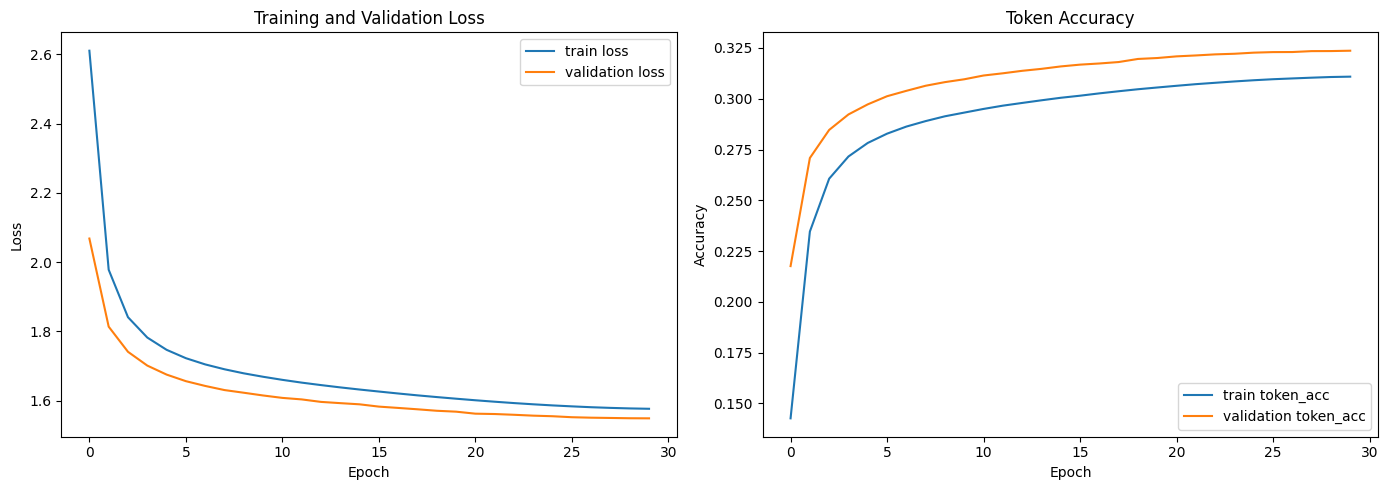

Best validation loss: 1.5486 at epoch 30
Total epochs trained: 30


In [17]:

history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='train loss')
axes[0].plot(history.history['val_loss'], label='validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

if 'token_acc' in history.history:
    axes[1].plot(history.history['token_acc'], label='train token_acc')
    axes[1].plot(history.history['val_token_acc'], label='validation token_acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Token Accuracy')
    axes[1].legend()

plt.tight_layout()
plt.show()

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
best_loss = float(np.min(history.history['val_loss']))
print(f'Best validation loss: {best_loss:.4f} at epoch {best_epoch}')
print(f'Total epochs trained: {len(history.history["loss"])}')



## Save the final training artifacts

This cell saves the final model, the tokenizer, the training config, and the training log.


In [18]:

model.save(str(FINAL_MODEL_PATH))

with open(TRAINING_CONFIG_PATH, 'w', encoding='utf-8') as handle:
    json.dump({
        'chatbot_name': CHATBOT_NAME,
        'config': CONFIG,
        'device': DEVICE,
        'seed': SEED,
    }, handle, indent=2)

print('Saved artifacts:')
print(f'  Best model:   {BEST_MODEL_PATH.resolve()}')
print(f'  Final model:  {FINAL_MODEL_PATH.resolve()}')
print(f'  Tokenizer:    {TOKENIZER_MODEL_PATH.resolve()}')
print(f'  Vocab:        {TOKENIZER_VOCAB_PATH.resolve()}')
print(f'  Config:       {TRAINING_CONFIG_PATH.resolve()}')
print(f'  Training log: {TRAINING_LOG_PATH.resolve()}')
print(f'  Checkpoints:  {CHECKPOINT_DIR.resolve()}')


Saved artifacts:
  Best model:   /content/best_optimus.keras
  Final model:  /content/final_optimus.keras
  Tokenizer:    /content/willow_tokenizer.model
  Vocab:        /content/willow_tokenizer.vocab
  Config:       /content/optimus_training_config.json
  Training log: /content/optimus_training_log.csv
  Checkpoints:  /content/checkpoints



## Reload the best checkpoint

This confirms that the saved best model can be loaded back into memory successfully.


In [5]:

try:
    reloaded_model = keras.models.load_model(
        str(BEST_MODEL_PATH),
        custom_objects={
            'TokenAndPositionEmbedding': TokenAndPositionEmbedding,
            'TransformerBlock': TransformerBlock,
            'WarmupCosineDecay': WarmupCosineDecay,
            'TiedLMHead': TiedLMHead,
        },
        compile=False,
    )
except Exception as error:
    print(f'Full load failed ({type(error).__name__}): {error}')
    print('Falling back to build_chatbot_model(...) + load_weights(...)')
    reloaded_model = build_chatbot_model(VOCAB_SIZE, CONFIG['max_seq_len'])
    reloaded_model.load_weights(str(BEST_MODEL_PATH))
# Weight tying is a runtime link between layer variables -- it is not stored in
# the .keras file. Re-establish it before running inference or fine-tuning.
retie_weights(reloaded_model)
print(f'Reloaded best model from: {BEST_MODEL_PATH.resolve()}')
reloaded_model.summary()


Weight tying active: lm_head shares the token embedding matrix.
Reloaded best model from: /home/janneesa/PycharmProjects/MetropoliaNeuralNetworkProject/chatbots/optimus/best_optimus.keras


Model: "optimus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed               │ (None, None, 512) │  8,388,608 │ input_ids[0][0]   │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, None, 512) │          0 │ embed[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_0 │ (None, None, 512) │  3,152,384 │ dropout[0][0],    │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_4 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_5 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_6 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_7 │ (None, None, 512) │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_layer_norm    │ (None, None, 512) │      1,024 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_head             │ (None, None,      │  8,208,000 │ final_layer_norm… │
│ (TiedLMHead)        │ 16000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,816,704 (159.52 MB)

 Trainable params: 33,624,704 (128.27 MB)

 Non-trainable params: 8,192,000 (31.25 MB)


## Text generation helpers

These helpers let the notebook run a few quick conversational tests after training.


In [6]:

def sample_next_token(logits, temperature=0.8, top_k=40):
    logits = logits.astype(np.float64)

    banned_ids = {PAD_ID, USER_ID, ASSISTANT_ID}
    for banned_id in banned_ids:
        if 0 <= banned_id < len(logits):
            logits[banned_id] = -1e10

    if temperature <= 0:
        return int(np.argmax(logits))

    logits = logits / temperature

    if top_k is not None and top_k > 0:
        top_indices = np.argpartition(logits, -top_k)[-top_k:]
        top_logits = logits[top_indices]
        probs = np.exp(top_logits - np.max(top_logits))
        probs = probs / np.sum(probs)
        return int(np.random.choice(top_indices, p=probs))

    probs = np.exp(logits - np.max(logits))
    probs = probs / np.sum(probs)
    return int(np.random.choice(np.arange(len(logits)), p=probs))


def generate_reply(model, conversation_turns: list[str], max_new_tokens=80, temperature=0.8, top_k=40):
    prompt_ids = [BOS_ID]
    for i, turn in enumerate(conversation_turns):
        role_token = SPECIAL_USER if i % 2 == 0 else SPECIAL_ASSISTANT
        prompt_ids.extend(encode_turn(role_token, normalize_text(turn)))

    prompt_ids.append(ASSISTANT_ID)
    generated = prompt_ids[:]
    new_tokens = []

    for _ in range(max_new_tokens):
        # Improvement #5 (partial -- no-padding inference):
        # The model now accepts shape=(None,) so we pass only the actual tokens,
        # trimmed to the last max_seq_len positions if the context is long.
        # No zero-padding is added, avoiding attention over empty padding positions.
        #
        # True KV cache: store K and V from previous steps and only compute
        # attention for the single new token each step. Requires a custom
        # MultiHeadAttention that exposes past_key_value state -- future work.
        x = generated[-CONFIG['max_seq_len']:]        # trim to window, no padding
        x_tensor = np.array([x], dtype=np.int32)      # shape: (1, current_len)

        logits = model(x_tensor, training=False)[0].numpy()
        next_logits = logits[-1]                       # last position (no padding offset needed)
        next_id = sample_next_token(next_logits, temperature=temperature, top_k=top_k)

        if next_id in (EOS_ID, SEP_ID):
            break

        generated.append(next_id)
        new_tokens.append(next_id)

    return sp.decode(new_tokens).strip()



## Quick chat preview

This is a simple sanity check. It lets you see how the model responds to a small fixed prompt set after training.


In [13]:

chat_model = reloaded_model

test_prompts = [
    'hello, how are you doing today?',
    'i had a really bad day at work.',
    'what do you like to do for fun?',
    'can you help me with something?',
    'i just got a promotion!',
    'do you ever feel lonely?',
    'what is your favorite food?',
    'i am feeling much better now, thanks!',
]

conversation_turns = []
for prompt in test_prompts:
    print('─' * 60)
    print(f'You:  {prompt}')
    reply = generate_reply(
        chat_model,
        conversation_turns + [prompt],
        max_new_tokens=CONFIG['preview_max_new_tokens'],
        temperature=CONFIG['preview_temperature'],
        top_k=CONFIG['preview_top_k'],
    )
    print(f'Bot:  {reply}')
    conversation_turns.append(prompt)
    conversation_turns.append(reply)

print('─' * 60)


────────────────────────────────────────────────────────────
You:  hello, how are you doing today?
Bot:  I am doing a good job I am doing. You are doing well
────────────────────────────────────────────────────────────
You:  i had a really bad day at work.
Bot:  How are you doing today?
────────────────────────────────────────────────────────────
You:  what do you like to do for fun?
Bot:  I am going to school for fun though.
────────────────────────────────────────────────────────────
You:  can you help me with something?
Bot:  Yeah, but I like going to college
────────────────────────────────────────────────────────────
You:  i just got a promotion!
Bot:  That would be a great promotion.
────────────────────────────────────────────────────────────
You:  do you ever feel lonely?
Bot:  Yeah, it is. I am now busy sometimes
────────────────────────────────────────────────────────────
You:  what is your favorite food?
Bot:  I'm going to cook every day so I'm new to the food
──────────────